# 01 - Data Cleaning (Preprocessing)

This notebook extracts data from the compressed `.csv.gz` file and saves the processed data under `data/processed` in dedicated subfolders.
The files created are:
- `extracted_data/data_##_##.csv` (extracted data)
- `filtered_data/cleaned_data_##_##.csv` (filtered data)
- `log_return_data/log_returns_data_##_##.csv` (log returns on filtered data)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Compressed CSV File

In [2]:
# Define the path to the compressed CSV file
FILE_NAME = 'data_00_20'
# Define a list of tickers to exclude (modify this list as needed)
EXCLUDED_TICKERS = []  # Example: ['TICKER1', 'TICKER2', 'TICKER3']


file_path = f'../data/raw/{FILE_NAME}.csv.gz'

# Read the compressed CSV file
df = pd.read_csv(file_path)
print(f"Total rows (raw): {len(df)}")
print(f"Total columns: {len(df.columns)}")

# Standardize timestamp column
df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d', errors='coerce')

# Remove rows with invalid/missing timestamp and keep chronological order
rows_before = len(df)
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
rows_removed_invalid_ts = rows_before - len(df)

print(f"Rows removed due to invalid/missing timestamp: {rows_removed_invalid_ts}")
print(f"Total rows after timestamp cleaning: {len(df)}")

Total rows (raw): 5334
Total columns: 503
Rows removed due to invalid/missing timestamp: 0
Total rows after timestamp cleaning: 5334


## 3. Explore Data Structure

In [3]:
# Display first few rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   timestamp   A  AAL  AAP      AAPL  ABBV     ABC    ABMD        ABT  ACN  \
0 1999-11-01 NaN  NaN  NaN  0.693035   NaN  3.4225  10.250  37.714036  NaN   
1 1999-11-02 NaN  NaN  NaN  0.716517   NaN  3.3900  10.315  35.552800  NaN   
2 1999-11-03 NaN  NaN  NaN  0.727678   NaN  3.2800  10.250  34.439436  NaN   
3 1999-11-04 NaN  NaN  NaN  0.746606   NaN  3.2500  10.470  35.440528  NaN   
4 1999-11-05 NaN  NaN  NaN  0.788481   NaN  3.1550  11.315  35.964464  NaN   

   ...    XLNX     XOM      XRAY     XRX  XYL      YUM  ZBH       ZBRA   ZION  \
0  ...  39.375  37.375  7.603326  110.00  NaN  10.1400  NaN  26.222196  59.06   
1  ...  40.095  37.060  7.876659  105.52  NaN   9.9850  NaN  25.391086  60.81   
2  ...  42.345  36.500  7.686659  105.76  NaN   9.8125  NaN  24.946642  60.06   
3  ...  42.875  36.500  7.709992  107.00  NaN   9.8125  NaN  24.444420  60.63   
4  ...  44.095  35.310  7.916659  103.52  NaN  10.1100  NaN  24.417753  62.19   

   ZTS  
0  NaN  
1  NaN  
2  

## 4. Save Processed Data

In [7]:
# Define the output directory
output_dir = Path(f'../data/processed/{FILE_NAME}')

# Create the directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

# Save the data as CSV
output_path = output_dir / f'{FILE_NAME}.csv'
df.to_csv(output_path, index=False)

print(f"Data saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / (1024*1024):.2f} MB")

Data saved to: ..\data\processed\data_00_20\data_00_20.csv
File size: 15.35 MB


# S&P 500 Stock Data Analysis

Analysis of historical stock quotations for S&P 500 companies, including:
- Data filtering
- Daily returns calculation

## 1. Load Data

In [8]:
# Load the extracted data
data_path = Path(f'../data/processed/{FILE_NAME}/{FILE_NAME}.csv')
df = pd.read_csv(data_path, parse_dates=['timestamp'])

# Ensure timestamp integrity in the analysis stage
rows_before = len(df)
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
rows_removed_invalid_ts_analysis = rows_before - len(df)

print(f"Rows removed due to invalid/missing timestamp (analysis load): {rows_removed_invalid_ts_analysis}")
print(f"Timestamp range: {df['timestamp'].min().strftime('%Y-%m-%d')} to {df['timestamp'].max().strftime('%Y-%m-%d')}")
print(f"Total records: {len(df)}")

# Extract ticker names (excluding timestamp)
ticker_cols = df.columns[1:].tolist()

# Core representation: pandas DataFrame (excluding timestamp)
prices_df = df[ticker_cols].copy()

# Display basic information
print("\nDataset shape (excluding timestamp):", prices_df.shape, "# (rows=time, cols=tickers)")
print("N. of dates (rows):", prices_df.shape[0])
print("N. of tickers/stocks (columns):", prices_df.shape[1])
print("\nColumn names (tickers/stocks):")
print(ticker_cols)

Rows removed due to invalid/missing timestamp (analysis load): 0
Timestamp range: 1999-11-01 to 2021-01-12
Total records: 5334

Dataset shape (excluding timestamp): (5334, 502) # (rows=time, cols=tickers)
N. of dates (rows): 5334
N. of tickers/stocks (columns): 502

Column names (tickers/stocks):
['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'ALXN', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'ANSS', 'ANTM', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APTV', 'ARE', 'ATO', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AZO', 'BA', 'BAC', 'BAX', 'BBY', 'BDX', 'BEN', 'BF-B', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLK', 'BLL', 'BMY', 'BR', 'BRK.B', 'BSX', 'BWA', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CE', 'CERN', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'C

In [9]:
def plot_quotations_per_day(quotes_per_day, max_quotes, file_name, is_filtered=False, 
                            min_quotes=None, n_days=None):
    # Create three subplots stacked vertically
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(14, 12))
    
    quotations_values = quotes_per_day.values
    bin_width = max_quotes / 50
    bins_sequence = [i * bin_width for i in range(51)]
    
    # Determine title suffix
    title_suffix = f" - FILTERED (> {min_quotes} quotations)" if is_filtered else ""
    xlabel_suffix = "Days" if is_filtered else "Timeline"
    
    # Plot 1: Time series of quotations per day
    ax0.plot(range(len(quotes_per_day)), quotations_values, linewidth=1.5, color='steelblue')
    ax0.axhline(y=max_quotes, color='red', linestyle='--', linewidth=2, label=f'Max Quotations ({max_quotes})')
    ax0.set_xlim(0, len(quotes_per_day) - 1)
    ax0.set_ylim(0, max_quotes * 1.1)
    ax0.legend(loc='upper right', fontsize=10, shadow=True)
    ax0.set_xlabel(xlabel_suffix, fontsize=12, fontweight='bold')
    ax0.set_ylabel('Count (Quotations)', fontsize=12, fontweight='bold')
    ax0.set_title(f'Available Quotations per Day Over Time (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax0.grid(True, alpha=0.3)
    
    # Plot 2: Full histogram
    ax1.hist(quotations_values, bins=bins_sequence, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlim(0, max_quotes + 1)
    ax1.set_ylim(0, (n_days if n_days else len(quotes_per_day)) * 1.1)
    ax1.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Distribution of Daily Quotation Counts (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 3: Absolute frequency histogram for values 0-10
    counts = pd.Series(quotes_per_day).value_counts().sort_index()
    for i in range(11):
        if i not in counts.index:
            counts[i] = 0
    counts = counts.sort_index()[:11]
    ax2.bar(range(11), counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.set_xlim(-0.5, 10.5)
    ax2.set_ylim(0, counts.max() * 1.1)
    ax2.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Distribution of Daily Quotation Counts (Zoom 0-10) (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax2.set_xticks(range(11))
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 2. Data Quality Checks and Cleaning

This dataset is already cleaned with:
- Survival bias removed
- Ticker changes accounted for
- Stock splits/reverse splits handled

We'll verify data quality and set a minimum threshold for quotations per stock.

In [10]:
missing_per_col = prices_df.isna().sum()
total_missing = int(missing_per_col.sum())
n_cells = prices_df.shape[0] * prices_df.shape[1]
missing_pct = (total_missing / n_cells) * 100

print("Missing values per column:")
for ticker in ticker_cols:
    print(f"{ticker}: {missing_per_col[ticker]}")

print(f"\nTotal missing values: {total_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Missing values per column:
A: 13
AAL: 1484
AAP: 521
AAPL: 0
ABBV: 3312
ABC: 0
ABMD: 0
ABT: 0
ACN: 432
ADBE: 0
ADI: 0
ADM: 0
ADP: 0
ADSK: 0
AEE: 0
AEP: 0
AES: 0
AFL: 0
AIG: 0
AIV: 0
AIZ: 1070
AJG: 0
AKAM: 0
ALB: 0
ALGN: 314
ALK: 301
ALL: 0
ALLE: 3534
ALXN: 0
AMAT: 0
AMCR: 4932
AMD: 0
AME: 0
AMGN: 0
AMP: 1476
AMT: 0
AMZN: 0
ANET: 3671
ANSS: 0
ANTM: 295
AON: 0
AOS: 0
APA: 0
APD: 0
APH: 0
APTV: 3032
ARE: 0
ATO: 0
ATVI: 0
AVB: 0
AVGO: 2455
AVY: 0
AWK: 2130
AXP: 0
AZO: 0
BA: 0
BAC: 0
BAX: 0
BBY: 0
BDX: 0
BEN: 0
BF-B: 0
BIIB: 0
BIO: 0
BK: 0
BKNG: 0
BKR: 4446
BLK: 0
BLL: 0
BMY: 0
BR: 1863
BRK.B: 0
BSX: 0
BWA: 0
BXP: 0
C: 0
CAG: 0
CAH: 0
CARR: 5127
CAT: 0
CB: 0
CBOE: 2670
CBRE: 1157
CCI: 0
CCL: 0
CDNS: 0
CDW: 3434
CE: 1312
CERN: 0
CF: 1452
CFG: 3747
CHD: 0
CHRW: 0
CHTR: 2559
CI: 0
CINF: 0
CL: 0
CLX: 0
CMA: 0
CMCSA: 0
CME: 778
CMG: 1567
CMI: 0
CMS: 0
CNC: 531
CNP: 0
COF: 0
COG: 0
COO: 0
COP: 0
COST: 0
COTY: 3424
CPB: 0
CPRT: 0
CRM: 1165
CSCO: 0
CSX: 0
CTAS: 0
CTL: 0
CTSH: 0
CTVA: 4921
CTXS: 0
CV

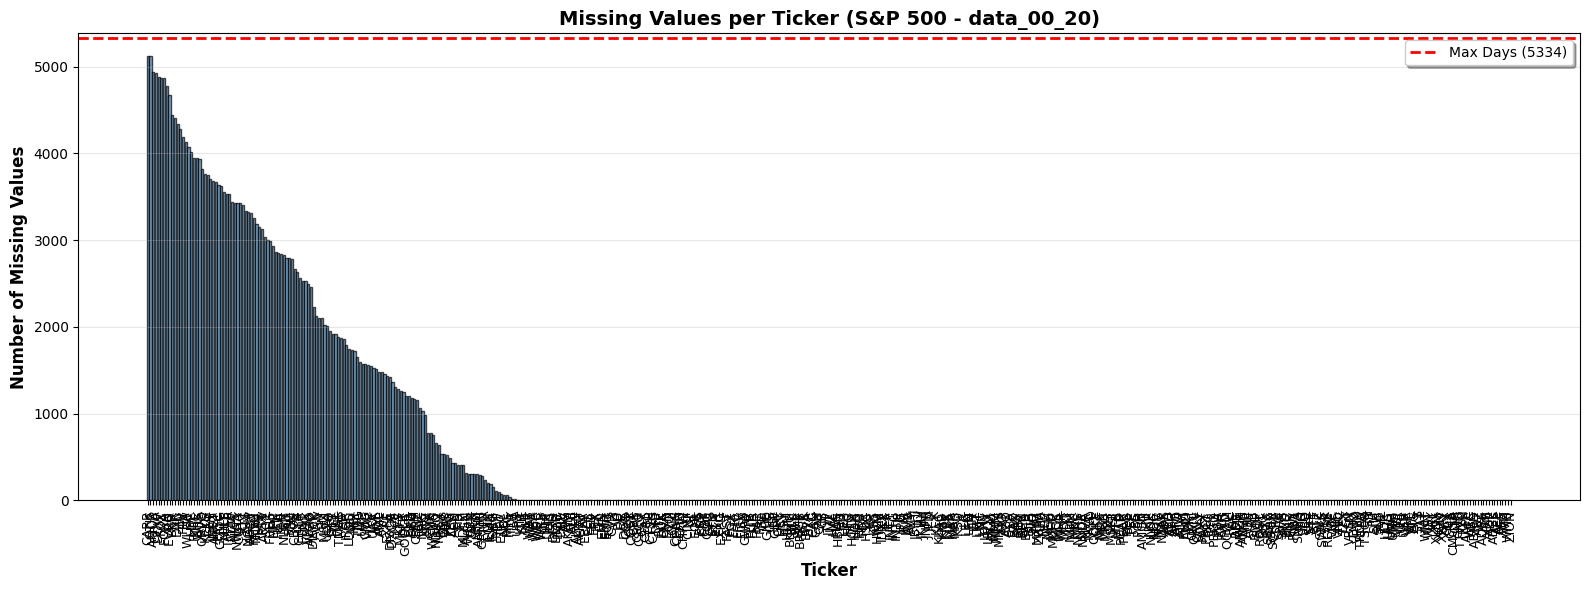

Missing values per ticker (sorted by count):
CARR: 5127
OTIS: 5127
AMCR: 4932
CTVA: 4921
DOW: 4875
FOX: 4870
FOXA: 4869
LIN: 4778
EVRG: 4676
BKR: 4446
IR: 4410
DXC: 4340
LW: 4285
FTV: 4193
UA: 4133
WLTW: 4069
HPE: 4016
PYPL: 3952
KHC: 3942
WRK: 3935
QRVO: 3816
KEYS: 3765
CFG: 3747
SYF: 3709
INFO: 3680
ANET: 3671
PAYC: 3635
GOOG: 3622
HLT: 3551
ALLE: 3534
TWTR: 3527
CDW: 3434
NWS: 3428
NWSA: 3428
COTY: 3424
IQV: 3400
ZTS: 3333
NCLH: 3324
ABBV: 3312
FANG: 3259
NOW: 3186
FB: 3157
PSX: 3131
APTV: 3032
XYL: 3007
FBHS: 2988
MPC: 2929
HII: 2864
HCA: 2856
KMI: 2838
NLSN: 2827
FLT: 2798
FRC: 2794
GM: 2780
CBOE: 2670
LYB: 2637
CHTR: 2559
FTNT: 2528
DG: 2525
VRSK: 2498
AVGO: 2455
DISCK: 2233
AWK: 2130
V: 2106
PM: 2104
MSCI: 2022
ULTA: 2007
CXO: 1949
DFS: 1914
TEL: 1914
DAL: 1885
TMUS: 1875
BR: 1863
IPGP: 1790
LDOS: 1748
WU: 1739
HBI: 1721
MA: 1650
TDG: 1600
UAL: 1574
CMG: 1567
VIAC: 1556
LYV: 1544
UAA: 1522
ICE: 1520
AAL: 1484
AMP: 1476
CF: 1452
EXPE: 1437
DISCA: 1428
DXCM: 1369
CE: 1312
LVS: 128

In [11]:
# Histogram of missing values per ticker, sorted by bar height
missing_sorted = missing_per_col.sort_values(ascending=False)
sorted_tickers = missing_sorted.index.tolist()
max_days = prices_df.shape[0]  # Max possible missing values

plt.figure(figsize=(16, 6))
plt.bar(
    range(len(sorted_tickers)),
    missing_sorted.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.7,
 )
plt.axhline(y=max_days, color='red', linestyle='--', linewidth=2, label=f'Max Days ({max_days})')
plt.legend(loc='upper right', fontsize=10, shadow=True)
plt.xlabel('Ticker', fontsize=12, fontweight='bold')
plt.ylabel('Number of Missing Values', fontsize=12, fontweight='bold')
plt.title(f'Missing Values per Ticker (S&P 500 - {FILE_NAME})', fontsize=14, fontweight='bold')
plt.xticks(range(len(sorted_tickers)), sorted_tickers, rotation=90, fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Missing values per ticker (sorted by count):")
for ticker, n_missing in zip(sorted_tickers, missing_sorted.values):
    print(f"{ticker}: {int(n_missing)}")

Quotations per day (across all tickers):
Min: 368
Max: 502
Mean: 446.32
Std: 39.43


C:\Users\dylan\AppData\Local\Temp\ipykernel_15756\2403393128.py:44: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, counts.max() * 1.1)


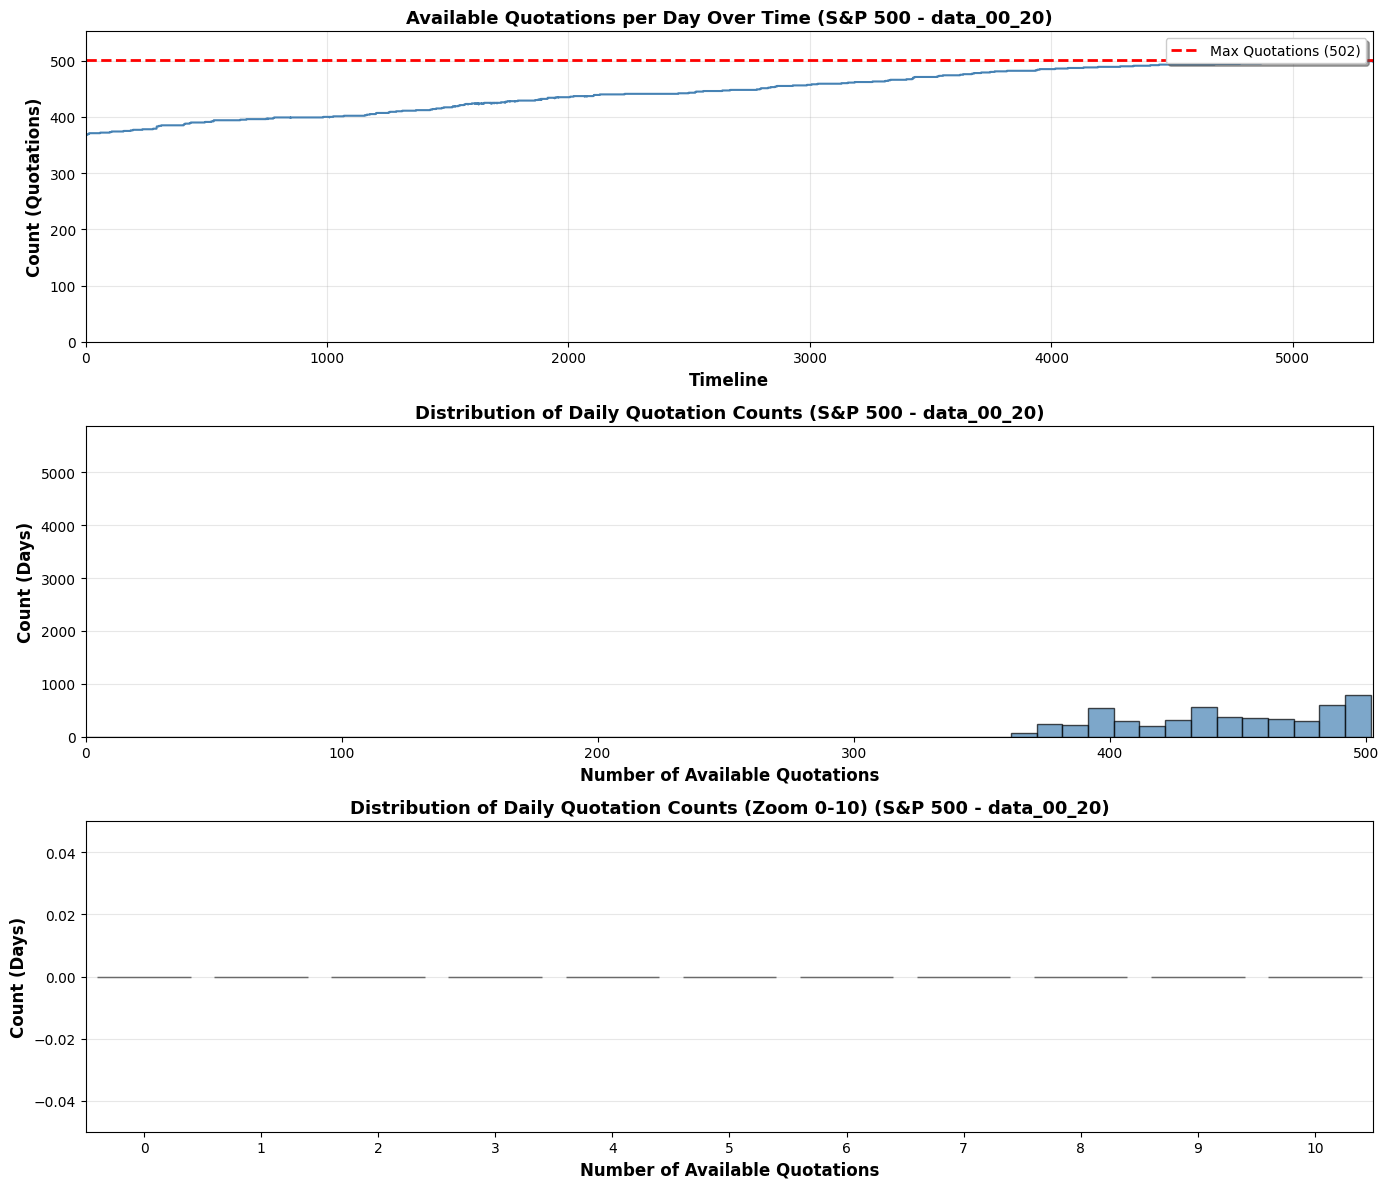

In [12]:
# Count available quotations per day (non-missing values across columns)
quotes_per_day = prices_df.notna().sum(axis=1)
max_quotes = prices_df.shape[1]  # Max possible quotations (all tickers available)

print(f"Quotations per day (across all tickers):")
print(f"Min: {quotes_per_day.min():.0f}")
print(f"Max: {quotes_per_day.max():.0f}")
print(f"Mean: {quotes_per_day.mean():.2f}")
print(f"Std: {quotes_per_day.std():.2f}")

# Plot using the reusable function
plot_quotations_per_day(quotes_per_day, max_quotes, FILE_NAME, 
                       is_filtered=False, n_days=prices_df.shape[0])

Days removed: 0
Days retained: 5334
Filtered dataset shape: (5334, 502)

Filtered days statistics:
Min quotations: 368
Max quotations: 502
Mean quotations: 446.32
Std quotations: 39.43


C:\Users\dylan\AppData\Local\Temp\ipykernel_15756\2403393128.py:44: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, counts.max() * 1.1)


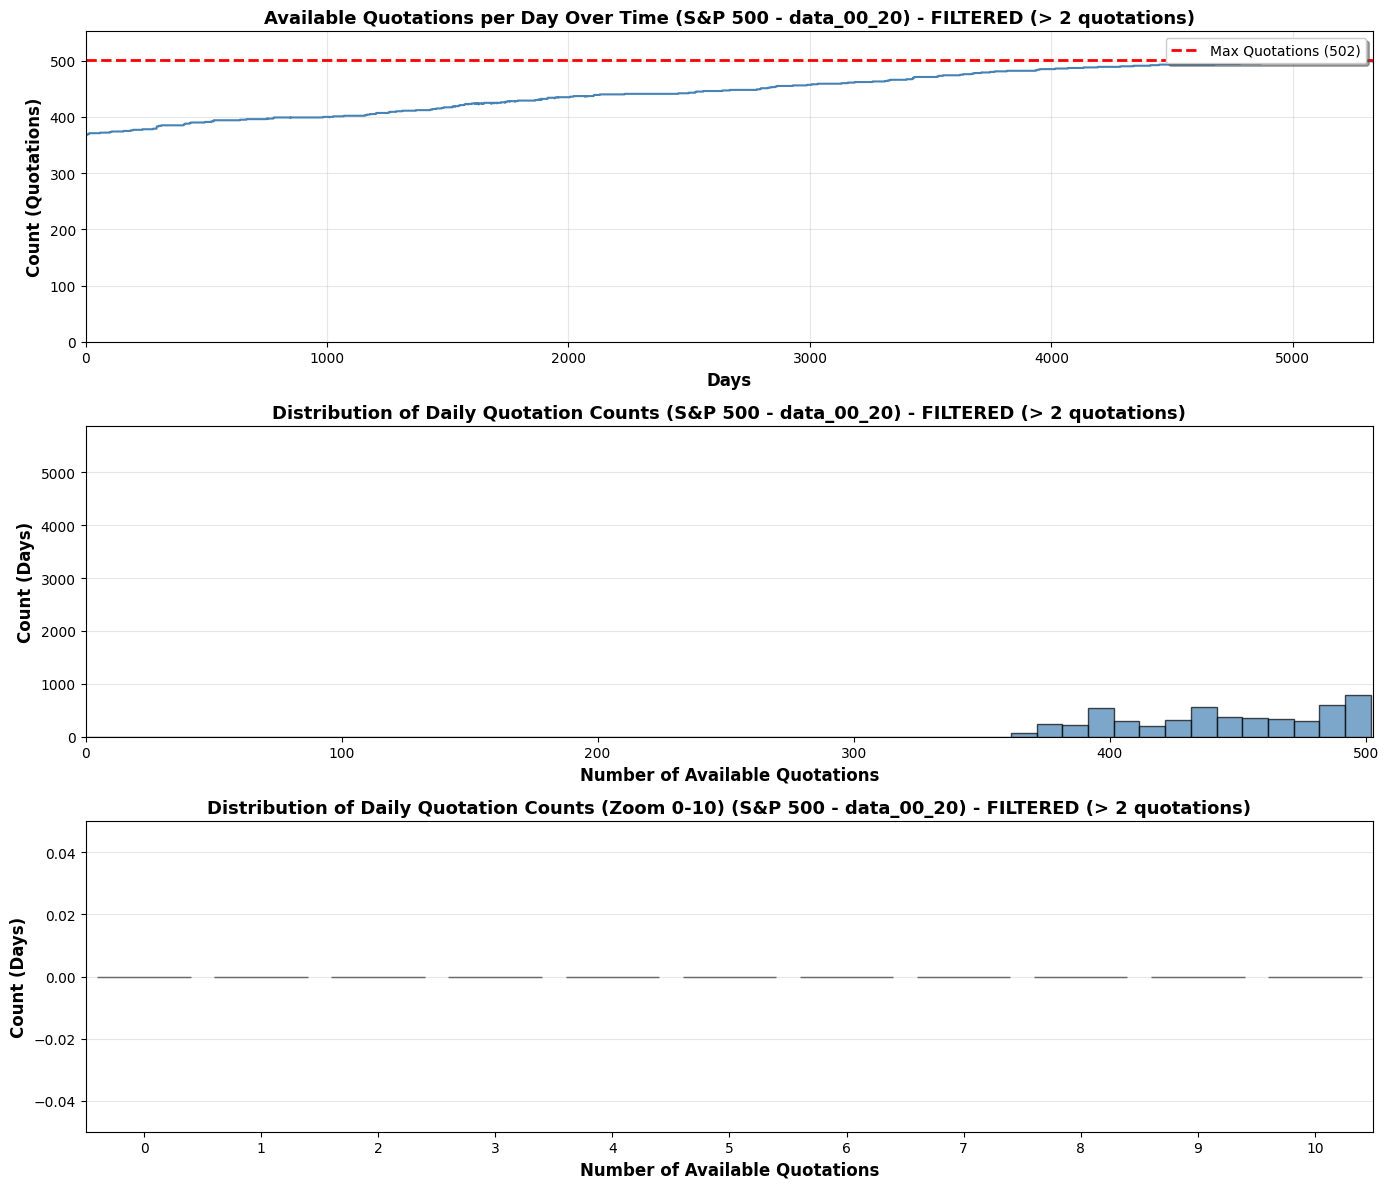

In [13]:
# Filter out days with less than or equal to MIN_QUOTES_PER_DAY quotations

MIN_QUOTES_PER_DAY = 2
valid_days_mask = quotes_per_day > MIN_QUOTES_PER_DAY
valid_day_indices = valid_days_mask[valid_days_mask].index.tolist()
max_quotes = prices_df.shape[1]  # Max possible quotations (all tickers available)

# Create filtered dataset
prices_filtered_df = prices_df.loc[valid_day_indices].copy()
quotes_per_day_filtered = quotes_per_day[valid_day_indices].copy()

print(f"Days removed: {(~valid_days_mask).sum()}")
print(f"Days retained: {valid_days_mask.sum()}")
print(f"Filtered dataset shape: {prices_filtered_df.shape}")
print(f"\nFiltered days statistics:")
print(f"Min quotations: {quotes_per_day_filtered.min():.0f}")
print(f"Max quotations: {quotes_per_day_filtered.max():.0f}")
print(f"Mean quotations: {quotes_per_day_filtered.mean():.2f}")
print(f"Std quotations: {quotes_per_day_filtered.std():.2f}")

# Plot using the reusable function with filtered data
plot_quotations_per_day(quotes_per_day_filtered, max_quotes, FILE_NAME,
                       is_filtered=True, min_quotes=MIN_QUOTES_PER_DAY, 
                       n_days=prices_df.shape[0])

In [14]:
# ===== AFTER FILTERING: Recalculate missing values per ticker =====
print("\n" + "="*70)
print("AFTER DAY FILTERING:")
print("="*70)

# Check for missing values in filtered dataset
missing_per_col_filtered = prices_filtered_df.isna().sum()
total_missing_filtered = int(missing_per_col_filtered.sum())
n_cells_filtered = prices_filtered_df.shape[0] * prices_filtered_df.shape[1]
missing_pct_filtered = (total_missing_filtered / n_cells_filtered) * 100

print("\nMissing values per ticker (after filtering):")
# Sort by missing values descending
missing_sorted_filtered = missing_per_col_filtered.sort_values(ascending=False)
sorted_tickers_filtered = missing_sorted_filtered.index.tolist()

for ticker in sorted_tickers_filtered:
    print(f"{ticker}: {missing_per_col_filtered[ticker]}")

print(f"\nTotal missing values (filtered): {total_missing_filtered}")
print(f"Missing percentage (filtered): {missing_pct_filtered:.2f}%")

# ===== FILTER TICKERS: Keep only those with 0 missing values =====
print("\n" + "="*70)
print("FILTERING TICKERS: Keep only those with ZERO missing values")
print("="*70)

# Identify tickers with NO missing values
no_missing_mask = missing_per_col_filtered == 0
tickers_with_complete_data = no_missing_mask[no_missing_mask].index.tolist()

# Filter the dataset to keep only complete tickers
prices_complete_df = prices_filtered_df[tickers_with_complete_data].copy()

# Validation prints
print(f"\nTickers with NO missing values: {no_missing_mask.sum()}")
print(f"Tickers removed (with missing values): {(~no_missing_mask).sum()}")
print(f"Final complete dataset shape: {prices_complete_df.shape}")
print(f"\nTickers with complete data ({len(tickers_with_complete_data)} total):")
print(tickers_with_complete_data)


AFTER DAY FILTERING:

Missing values per ticker (after filtering):
CARR: 5127
OTIS: 5127
AMCR: 4932
CTVA: 4921
DOW: 4875
FOX: 4870
FOXA: 4869
LIN: 4778
EVRG: 4676
BKR: 4446
IR: 4410
DXC: 4340
LW: 4285
FTV: 4193
UA: 4133
WLTW: 4069
HPE: 4016
PYPL: 3952
KHC: 3942
WRK: 3935
QRVO: 3816
KEYS: 3765
CFG: 3747
SYF: 3709
INFO: 3680
ANET: 3671
PAYC: 3635
GOOG: 3622
HLT: 3551
ALLE: 3534
TWTR: 3527
CDW: 3434
NWS: 3428
NWSA: 3428
COTY: 3424
IQV: 3400
ZTS: 3333
NCLH: 3324
ABBV: 3312
FANG: 3259
NOW: 3186
FB: 3157
PSX: 3131
APTV: 3032
XYL: 3007
FBHS: 2988
MPC: 2929
HII: 2864
HCA: 2856
KMI: 2838
NLSN: 2827
FLT: 2798
FRC: 2794
GM: 2780
CBOE: 2670
LYB: 2637
CHTR: 2559
FTNT: 2528
DG: 2525
VRSK: 2498
AVGO: 2455
DISCK: 2233
AWK: 2130
V: 2106
PM: 2104
MSCI: 2022
ULTA: 2007
CXO: 1949
DFS: 1914
TEL: 1914
DAL: 1885
TMUS: 1875
BR: 1863
IPGP: 1790
LDOS: 1748
WU: 1739
HBI: 1721
MA: 1650
TDG: 1600
UAL: 1574
CMG: 1567
VIAC: 1556
LYV: 1544
UAA: 1522
ICE: 1520
AAL: 1484
AMP: 1476
CF: 1452
EXPE: 1437
DISCA: 1428
DXCM:

In [15]:
# Filter out excluded tickers from the complete dataset
excluded_mask = prices_complete_df.columns.isin(EXCLUDED_TICKERS)
tickers_excluded = prices_complete_df.columns[excluded_mask].tolist()

if tickers_excluded:
    print(f"Excluding {len(tickers_excluded)} ticker(s):")
    print(tickers_excluded)
    
    # Remove excluded tickers
    prices_complete_df = prices_complete_df.drop(columns=tickers_excluded)
    print(f"\nDataset shape after excluding tickers: {prices_complete_df.shape}")
    print(f"Remaining tickers ({prices_complete_df.shape[1]} total):")
    print(prices_complete_df.columns.tolist())
else:
    print("No tickers excluded (EXCLUDED_TICKERS list is empty)")
    print(f"Total tickers: {prices_complete_df.shape[1]}")

No tickers excluded (EXCLUDED_TICKERS list is empty)
Total tickers: 362


,count,percent
gics_category,,
Industrials,56,15.47
Financials,50,13.81
Health Care,46,12.71
Information Technology,44,12.15
Consumer Discretionary,33,9.12
Consumer Staples,29,8.01
Real Estate,28,7.73
Utilities,24,6.63
Materials,20,5.52


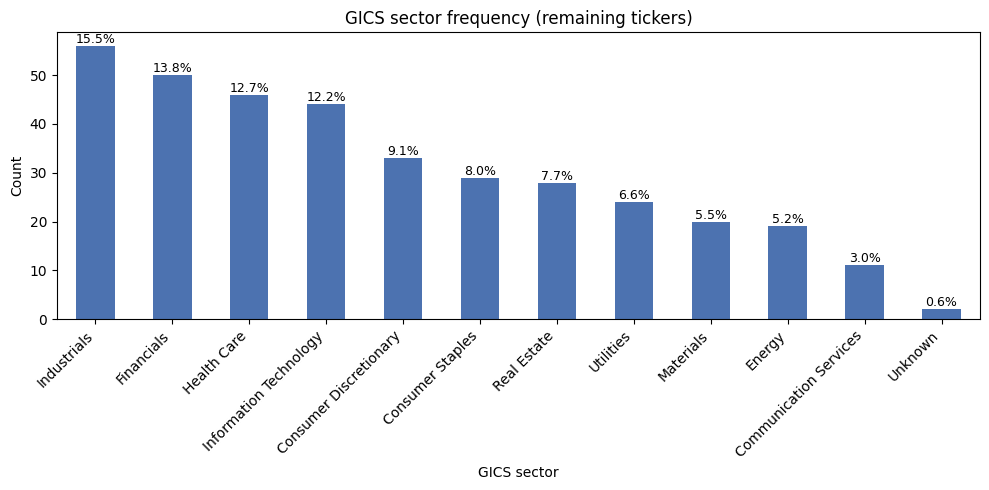

In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

mapping_path = Path('..') / 'data' / 'processed' / 'gics_by_ticker.csv'

gics_df = pd.read_csv(mapping_path)
remaining_tickers = set(prices_complete_df.columns)
gics_filtered = gics_df[gics_df["ticker"].isin(remaining_tickers)].copy()

if gics_filtered.empty:
    print("No GICS mappings found for the remaining tickers.")
else:
    sector_counts = (
        gics_filtered["gics_category"]
        .fillna("Unknown")
        .replace("", "Unknown")
        .value_counts()
        .sort_values(ascending=False)
    )
    sector_pct = (sector_counts / sector_counts.sum() * 100).round(2)

    display(pd.DataFrame({"count": sector_counts, "percent": sector_pct}))

    plt.figure(figsize=(10, 5))
    ax = sector_counts.plot(kind="bar", color="#4C72B0")
    ax.set_title("GICS sector frequency (remaining tickers)")
    ax.set_xlabel("GICS sector")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")

    for i, (count, pct) in enumerate(zip(sector_counts.values, sector_pct.values)):
        ax.text(i, count, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

In [18]:
import numpy as np
from pathlib import Path
import pandas as pd

N_TICKERS_TO_KEEP = 100  # change as needed
RANDOM_STATE = 42

if "prices_complete_df" not in globals():
    raise NameError("prices_complete_df not found. Run the previous cells first.")

if "gics_filtered" not in globals() or gics_filtered.empty:
    mapping_path = Path('..') / 'data' / 'processed' / FILE_NAME / 'gics_by_ticker.csv'
    gics_df = pd.read_csv(mapping_path)
    remaining_tickers = set(prices_complete_df.columns)
    gics_filtered = gics_df[gics_df["ticker"].isin(remaining_tickers)].copy()

if gics_filtered.empty:
    print("No GICS mappings found for the remaining tickers.")
else:
    gics_filtered["gics_category"] = (
        gics_filtered["gics_category"].fillna("Unknown").replace("", "Unknown")
    )
    unique_tickers = gics_filtered["ticker"].unique()
    if N_TICKERS_TO_KEEP > len(unique_tickers):
        print(
            f"Requested N={N_TICKERS_TO_KEEP} > available {len(unique_tickers)}. Using all tickers."
        )
        N_TICKERS_TO_KEEP = len(unique_tickers)

    sector_counts = gics_filtered["gics_category"].value_counts()
    sector_props = sector_counts / sector_counts.sum()
    raw_targets = sector_props * N_TICKERS_TO_KEEP
    target_counts = raw_targets.astype(int)
    remainder = N_TICKERS_TO_KEEP - target_counts.sum()
    if remainder > 0:
        order = (raw_targets - target_counts).sort_values(ascending=False).index.tolist()
        for i in range(remainder):
            target_counts[order[i % len(order)]] += 1

    rng = np.random.default_rng(RANDOM_STATE)
    selected = []
    for sector, n in target_counts.items():
        sector_tickers = gics_filtered.loc[
            gics_filtered["gics_category"] == sector, "ticker"
        ].unique()
        if n > len(sector_tickers):
            n = len(sector_tickers)
        if n > 0:
            selected.extend(rng.choice(sector_tickers, size=n, replace=False).tolist())

    if len(selected) < N_TICKERS_TO_KEEP:
        remaining_pool = [t for t in unique_tickers if t not in set(selected)]
        if remaining_pool:
            extra = rng.choice(
                remaining_pool,
                size=min(N_TICKERS_TO_KEEP - len(selected), len(remaining_pool)),
                replace=False,
            )
            selected.extend(extra.tolist())

    selected_set = set(selected)
    selected_tickers_ordered = [
        t for t in prices_complete_df.columns if t in selected_set
    ]
    prices_complete_df = prices_complete_df[selected_tickers_ordered].copy()

    print(f"Selected {prices_complete_df.shape[1]} tickers (stratified by GICS).")
    selected_counts = (
        gics_filtered[gics_filtered["ticker"].isin(selected_set)]
        ["gics_category"]
        .value_counts()
        .sort_values(ascending=False)
    )
    selected_pct = (selected_counts / selected_counts.sum() * 100).round(2)
    display(pd.DataFrame({"count": selected_counts, "percent": selected_pct}))

Selected 100 tickers (stratified by GICS).


,count,percent
gics_category,,
Industrials,15,15.0
Financials,14,14.0
Health Care,13,13.0
Information Technology,12,12.0
Consumer Discretionary,9,9.0
Real Estate,8,8.0
Consumer Staples,8,8.0
Utilities,7,7.0
Materials,5,5.0


## 3. Saving Filtered Data to CSV

In [19]:
# Build cleaned dataframe with timestamps using positional alignment (robust to dropped rows)
timestamps_for_complete = df.loc[prices_complete_df.index, 'timestamp'].to_numpy()
df_complete = prices_complete_df.reset_index(drop=True).copy()
df_complete.insert(0, 'timestamp', timestamps_for_complete)

# Do not drop rows here: timestamp cleaning is handled upstream
if df_complete['timestamp'].isna().any():
    raise ValueError("Found missing timestamps in df_complete. Check timestamp cleaning in the load step.")

# Define output directories
base_processed = Path(f'../data/processed/{FILE_NAME}')
filtered_dir = base_processed
log_return_dir = base_processed
filtered_dir.mkdir(parents=True, exist_ok=True)
log_return_dir.mkdir(parents=True, exist_ok=True)

# Define output paths
output_cleaned_path = filtered_dir / f'cleaned_{FILE_NAME}.csv'
output_log_returns_path = log_return_dir / f'log_returns_{FILE_NAME}.csv'

# Save cleaned prices to CSV
df_complete.to_csv(output_cleaned_path, index=False)

# Compute log-returns on cleaned prices and save to CSV
price_only = df_complete.drop(columns=['timestamp'])
log_returns_values = np.log(price_only).diff().iloc[1:].reset_index(drop=True)
log_returns_timestamps = df_complete[['timestamp']].iloc[1:].reset_index(drop=True)
log_returns_df = pd.concat([log_returns_timestamps, log_returns_values], axis=1)

# Safety checks: exactly one row less and no empty timestamps
expected_rows = len(df_complete) - 1
if len(log_returns_df) != expected_rows:
    raise ValueError(f"Unexpected log-returns length: {len(log_returns_df)} (expected {expected_rows})")
if log_returns_df['timestamp'].isna().any():
    raise ValueError("Found missing timestamps in log-returns output")

log_returns_df.to_csv(output_log_returns_path, index=False)

print(f"\nFiltered dataset saved to: {output_cleaned_path}")
print(f"Shape: {df_complete.shape} (rows=days, columns=tickers+timestamp)")
print(f"\nLog-returns dataset saved to: {output_log_returns_path}")
print(f"Shape: {log_returns_df.shape} (rows=days-1, columns=tickers+timestamp)")
print(f"\nTimestamp range in filtered data:")
print(f"  From: {df_complete['timestamp'].min()}")
print(f"  To: {df_complete['timestamp'].max()}")
print(f"\nTimestamp range in log-returns:")
print(f"  From: {log_returns_df['timestamp'].min()}")
print(f"  To: {log_returns_df['timestamp'].max()}")
print(f"\nFirst few rows (cleaned prices):")
print(df_complete.head())
print(f"\nFirst few rows (log-returns):")
print(log_returns_df.head())


Filtered dataset saved to: ..\data\processed\data_00_20\cleaned_data_00_20.csv
Shape: (5334, 101) (rows=days, columns=tickers+timestamp)

Log-returns dataset saved to: ..\data\processed\data_00_20\log_returns_data_00_20.csv
Shape: (5333, 101) (rows=days-1, columns=tickers+timestamp)

Timestamp range in filtered data:
  From: 1999-11-01 00:00:00
  To: 2021-01-12 00:00:00

Timestamp range in log-returns:
  From: 1999-11-02 00:00:00
  To: 2021-01-12 00:00:00

First few rows (cleaned prices):
   timestamp     ABC    ADP     AES       AIV     AJG   AKAM    ALL   AMZN  \
0 1999-11-01  3.4225  48.06  28.190  5.241807  25.655  174.3  28.69  69.13   
1 1999-11-02  3.3900  47.56  28.690  5.284424  25.750  192.8  28.31  66.44   
2 1999-11-03  3.2800  47.13  27.970  5.284424  26.250  190.9  28.69  65.81   
3 1999-11-04  3.2500  46.69  27.875  5.284424  26.530  173.3  29.13  63.06   
4 1999-11-05  3.1550  47.75  28.470  5.310543  27.750  174.3  29.44  64.94   

     BDX  ...    TRV    TYL     VAR 